# Neural Networks
## In this Lesson
* What is a Neural Networks
* London Cycle Hire Data
* How does a Neural Network Work?
* Vectors and Matrices
* Dot Product
* Activation Functions
* ???
* Back Propogation
* Genetic Algorithms
* ??

# What is a Neural Network?
In data science, an artificial neural network (commonly referred to as simply a "neural network") is a type of machine learning algorithm which can be used for supervised problems.

Artificial neural networks have been around since the 1800s, although in their simplest form, neural networks become linear regression. It wasn't until the 1940s that researchers took direct inspiration from biological systems when designing them. The key takeaway is that neural networks as a mathematical approach is not new, but advents in computer processing power have enabled deep learning and large language models.


# London Cycle Hire Data
For this session, we will be using a London bike hire data set [sourced from Kaggle](https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset). For convenience, the data is included in this Git repository.

Firstly, let us load the data using python to inspect.

In [1]:
# Pandas to read the data
import pandas as pd
# Display function to view data
from IPython.display import display

# Read excel
df = pd.read_csv("../data/london_cycle_hire.csv")

# Display
display(df)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...
17409,2017-01-03 19:00:00,1042,5.0,1.0,81.0,19.0,3.0,0.0,0.0,3.0
17410,2017-01-03 20:00:00,541,5.0,1.0,81.0,21.0,4.0,0.0,0.0,3.0
17411,2017-01-03 21:00:00,337,5.5,1.5,78.5,24.0,4.0,0.0,0.0,3.0
17412,2017-01-03 22:00:00,224,5.5,1.5,76.0,23.0,4.0,0.0,0.0,3.0


As you can see, the data contains the count of total cycles hired for a range of days between 2015 and 2017, combined with weather and other contextual information, such as holidays and weekends.

We want to be able to predict the total cycle hire, given these other factors.


# Sci-Kit Learn Example
If we want to use a neural network to predict the number of cycle hires, we can use Sci-Kit Learn to provide a model. This may be how you would look to use a neural network at a customer (rather than building your own code to train and execute one).

In [16]:

# Import our Neural Network Model (for regression problems)
from sklearn.neural_network import MLPRegressor
# Import a normaliser
from sklearn.preprocessing import MinMaxScaler
# Import r2 score to assess accuracy
from sklearn.metrics import r2_score

# It makes sense to normalise data before we pass it to an ANN
numeric_cols = df.select_dtypes(include='number').columns
scaler = MinMaxScaler()
normalized_array = scaler.fit_transform(df[numeric_cols])
normalized_df = pd.DataFrame(normalized_array, columns=numeric_cols)

# Split our data at 70%
# Question: Why does it not make sense to use a random split method for this data?
split_point = int(len(normalized_df)*0.7)
train = df[:split_point]
test = df[split_point:]

# Variable for the features we will train with
features = ["t1", "t2", "hum", "wind_speed", "weather_code", "is_holiday", "is_weekend", "season"]

# Define our model object, including some hyperparameters
ann = MLPRegressor(
    hidden_layer_sizes=(10, 5, 3,),
    activation = "relu"
)

# Fit model
ann.fit(train[features], train["cnt"])

# Use model to predict
predictions = ann.predict(test[features])

# Evaluate model using r2
print("r2 score:")
print(r2_score(test["cnt"], predictions))



r2 score:
0.2417894431605878


C:\Users\jlawton\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


An R2 score of 0.25 is respectable, in practice we should expect to be able to improve this with further feature engineering and/or more hidden nodes. In our [multilinear regression lesson](https://github.com/Jack-Lawton/python-resources/blob/main/lessons/Multilinear%20Regression.ipynb), we reached an R2 of over 0.5 on the same data set (over weekend data only).

For more information on hyperparameters available for this neural network, refer to the [Sci-Kit Learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor).

# How Does a Neural Network Work?
When implementing any machine learning algorithm, it's useful to know how it works. Neural networks are no different. Let's dive into them and derive our own without using Sci-Kit Learn.

First, what does a neural network look like? Let's visualise the one we just trained.

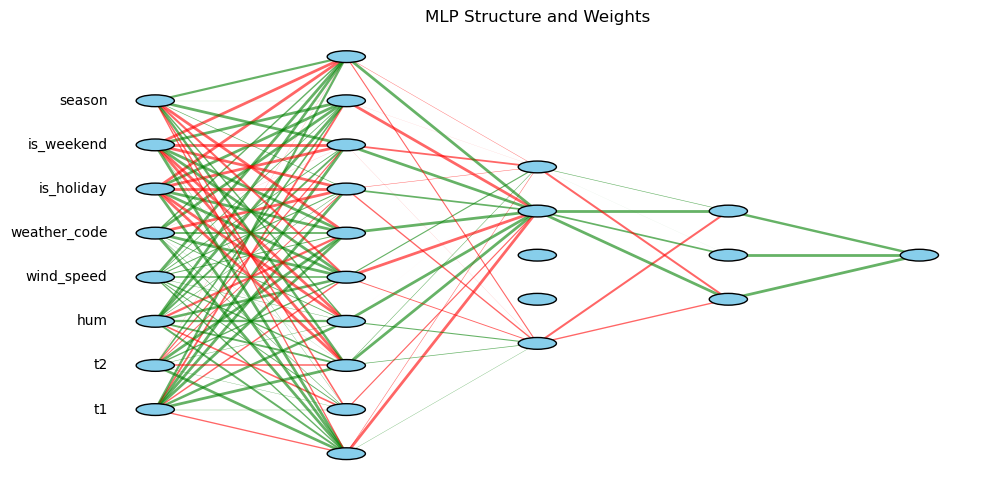

In [21]:
import matplotlib.pyplot as plt
import numpy as np


# Function to plot a neural network (thanks to ChatGPT)
def plot_mlp_structure(mlp, feature_names=None):
    layer_sizes = [coefs.shape[0] for coefs in mlp.coefs_] + [mlp.coefs_[-1].shape[1]]
    fig, ax = plt.subplots(figsize=(10, 5))

    # Coordinates
    layer_count = len(layer_sizes)
    y_spacing = 1.5
    x_spacing = 2

    node_positions = {}
    for i, layer_size in enumerate(layer_sizes):
        x = i * x_spacing
        for j in range(layer_size):
            y = j * y_spacing - (layer_size - 1) * y_spacing / 2
            node_positions[(i, j)] = (x, y)
            ax.add_patch(plt.Circle((x, y), 0.2, color='skyblue', ec='black', zorder=3))
            if i == 0 and feature_names:
                ax.text(x - 0.5, y, feature_names[j], ha='right', va='center')

    # Draw connections with weight color
    for i, (layer_weights, layer_biases) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        for j, from_node in enumerate(layer_weights):
            for k, weight in enumerate(from_node):
                x1, y1 = node_positions[(i, j)]
                x2, y2 = node_positions[(i+1, k)]
                color = 'red' if weight < 0 else 'green'
                linewidth = min(1.0, abs(weight)) * 2
                ax.plot([x1, x2], [y1, y2], color=color, linewidth=linewidth, alpha=0.6, zorder=1)

    ax.axis('off')
    ax.set_title("MLP Structure and Weights")
    plt.tight_layout()
    plt.show()
    
    
plot_mlp_structure(ann, feature_names=features)

Here we can see the neural network has 7 input nodes and 1 output node, between are 3 hidden layers with 10, 5 and 3 nodes. The size and colour of the lines between each node show the strength and sign of the weights between them.

Let's discuss the maths behind a neural network, as an example we can use this simplified network with 3 input nodes, a 4 node hidden layer and 2 output nodes.

<p><img align="center" width="50%" src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/46/Colored_neural_network.svg/800px-Colored_neural_network.svg.png"></p><br>

Let's define our three layers as vectors. Input layer, $\boldsymbol{i}$, hidden layer, $\boldsymbol{h}$ and output layer $\boldsymbol{\omega}$.

$\boldsymbol{i} = \begin{bmatrix}
i_1 & i_2 & i_3
\end{bmatrix}$

$\boldsymbol{h} = \begin{bmatrix}
h_1 & h_2 & h_3 & h_4
\end{bmatrix}$

$\boldsymbol{\omega} = \begin{bmatrix}
\omega_1 & \omega_2
\end{bmatrix}$

Between each layer every node has a weight to every other node. These weights can be described as matrices.

$\mathbf{W}_{ih} = 
\begin{bmatrix}
W_{ih11} & W_{ih12} & W_{ih13} & W_{ih14} \\
W_{ih21} & W_{ih22} & W_{ih23} & W_{ih24} \\
W_{ih31} & W_{ih32} & W_{ih33} & W_{ih34}
\end{bmatrix}$

$\mathbf{W}_{h\omega} = 
\begin{bmatrix}
W_{h\omega11} & W_{h\omega12}\\
W_{h\omega21} & W_{h\omega22}\\
W_{h\omega31} & W_{h\omega32}\\
W_{h\omega41} & W_{h\omega42}
\end{bmatrix}$

Note $\mathbf{W}_{ih}$ is a 3x4 matrix as there are 3 nodes in the input and 4 in the hidden layer. The same is true for $\mathbf{W}_{h\omega}$ between the hidden layer and output layer (4x2).

To calculate the first node in the hidden layer (as an example), we would need to multiply the input nodes by the weights connecting them to the first hidden node, i.e.

$h_1 = f(i_1W_{ih11} + i_2W_{ih21} + i_3W_{ih31})$

Where $f$ is the activation function (we will get to this).

## Dot Product

We can use the matrix dot product to simplify our mathematical expressions here. In a simple case, the dot product means:
$
\begin{bmatrix}
a_{1} & a_{2}
\end{bmatrix}
\cdot
\begin{bmatrix}
b_{11} & b_{12} & b_{13} \\
b_{21} & b_{22} & b_{23}
\end{bmatrix}
=
\begin{bmatrix}
a_{1}b_{11} + a_{2}b_{21} & a_{1}b_{12} + a_{2}b_{22} & a_{1}b_{13} + a_{2}b_{23}
\end{bmatrix}$

Meaning,

$\boldsymbol{h} = f(\boldsymbol{i}\cdot\mathbf{W}_{ih})$

and

$\boldsymbol{\omega} = \boldsymbol{h}\cdot\mathbf{W}_{h\omega}$

Note, this is just mathematical convenience, the underlying logic that all the weights are applied and multipled through is still true. I have also not included an activation function on the output layer, optionally, this can be done.

# Activation Functions
tbc..